# Evaluación robusta de clasificadores
## Notebook 07 — Validación cruzada, métricas por clase y curvas ROC

Este notebook complementa el notebook 06. Toma los mismos datos y clasificadores
para las **cuatro técnicas** (STFT, CWT, SST, WPD), pero reemplaza el split único
por evaluaciones más rigurosas y corrige el sesgo de distribución entre train y test.

---

## Por qué el split de bloques alternos del notebook 06 tiene un problema

El split asignaba bloques pares a train e impares a test, generando:

| Conjunto | Clase 0 (ojos abiertos) | Clase 1 (ojos cerrados) |
|----------|------------------------|------------------------|
| Train    | 45.8 %                 | 54.2 %                 |
| Test     | **62.9 %**             | **37.1 %**             |

Un clasificador que prediga siempre 'ojos abiertos' obtiene 45.8 % en train
pero 62.9 % en test — sin aprender nada. Eso puede hacer que un modelo malo
parezca que 'mejora' al pasar de train a test.

## Soluciones implementadas

1. **Balanced Accuracy** — promedia el recall de cada clase, eliminando el efecto
   del desbalance. Un clasificador trivial siempre obtiene BAcc = 0.5.

2. **TimeSeriesSplit (5-fold)** — repite la evaluación con ventanas temporales
   crecientes. El resultado es `media ± std`, permitiendo saber si las diferencias
   entre técnicas son consistentes o producto de una partición afortunada.

3. **Curvas ROC** — muestra el tradeoff completo entre sensibilidad y especificidad
   para las 4 técnicas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
warnings.filterwarnings('ignore')

# Paleta fija para las 4 técnicas
COLORS = {
    'STFT': '#2980b9',
    'CWT':  '#c0392b',
    'SST':  '#27ae60',
    'WPD':  '#e67e22',
}
TECNICAS = ['STFT', 'CWT', 'SST', 'WPD']

# Cargar los 4 datasets
features_stft = pd.read_csv('data/features/features_stft.csv')
features_cwt  = pd.read_csv('data/features/features_cwt.csv')
features_sst  = pd.read_csv('data/features/features_sst.csv')
features_wpd  = pd.read_csv('data/features/features_wpd.csv')

datasets = {
    'STFT': features_stft,
    'CWT':  features_cwt,
    'SST':  features_sst,
    'WPD':  features_wpd,
}

Xs = {name: df.drop('label', axis=1).values for name, df in datasets.items()}
ys = {name: df['label'].values             for name, df in datasets.items()}

feature_names      = features_stft.columns[:-1].tolist()
features_por_canal = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
canales_todos = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
canales_alfa  = ['O1','O2','P7','P8']

def get_feature_indices(feat_names, canales):
    idxs = []
    for canal in canales:
        for feat in features_por_canal:
            col = f'{canal}_{feat}'
            if col in feat_names:
                idxs.append(feat_names.index(col))
    return idxs

idx_config_a = get_feature_indices(feature_names, canales_todos)
idx_config_b = get_feature_indices(feature_names, canales_alfa)

print('Datasets cargados:')
for name, X in Xs.items():
    print(f'  {name}: {X.shape}, clase 0={np.sum(ys[name]==0)}, clase 1={np.sum(ys[name]==1)}')
print(f'Config A: {len(idx_config_a)} features | Config B: {len(idx_config_b)} features')


Datasets cargados:
  STFT: (231, 56), clase 0=125, clase 1=106
  CWT: (231, 56), clase 0=125, clase 1=106
  SST: (231, 56), clase 0=125, clase 1=106
  WPD: (231, 56), clase 0=125, clase 1=106
Config A: 56 features | Config B: 16 features


In [2]:
## Split único temporal (igual que en notebook 06)

# Se conserva el mismo split para que la tabla resumen pueda comparar
# split único vs cross-validación en las mismas condiciones.
n_samples  = Xs['STFT'].shape[0]
block_size = 30
block_numbers = np.arange(n_samples) // block_size
train_idx = np.where(block_numbers % 2 == 0)[0]
test_idx  = np.where(block_numbers % 2 == 1)[0]

# Construir splits para las 4 técnicas
splits = {}
for name in TECNICAS:
    X, y = Xs[name], ys[name]
    sc_a, sc_b = StandardScaler(), StandardScaler()
    Xtr_a = X[train_idx][:, idx_config_a]
    Xte_a = X[test_idx ][:, idx_config_a]
    Xtr_b = X[train_idx][:, idx_config_b]
    Xte_b = X[test_idx ][:, idx_config_b]
    splits[name] = {
        'X_tr_a': sc_a.fit_transform(Xtr_a), 'X_te_a': sc_a.transform(Xte_a),
        'X_tr_b': sc_b.fit_transform(Xtr_b), 'X_te_b': sc_b.transform(Xte_b),
        'y_tr':   y[train_idx], 'y_te': y[test_idx],
    }

print(f'Train: {len(train_idx)} muestras  |  Test: {len(test_idx)} muestras')
s0 = splits['STFT']
print(f'Distribucion train: clase 0 = {np.mean(s0["y_tr"]==0):.1%}')
print(f'Distribucion test:  clase 0 = {np.mean(s0["y_te"]==0):.1%}')
print('\nAtencion: diferencia de distribucion entre train y test -> ver Seccion 1 (Balanced Accuracy).')


Train: 120 muestras  |  Test: 111 muestras
Distribucion train: clase 0 = 49.2%
Distribucion test:  clase 0 = 59.5%

Atencion: diferencia de distribucion entre train y test -> ver Seccion 1 (Balanced Accuracy).


In [3]:
## Definir clasificadores y entrenar split único (24 combinaciones)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'model':   model,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'acc':     accuracy_score(y_test, y_pred),
        'bacc':    balanced_accuracy_score(y_test, y_pred),
        'f1':      f1_score(y_test, y_pred, average='macro'),
        'auc':     roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan'),
        'cm':      confusion_matrix(y_test, y_pred),
    }

results = []
print('Entrenando 24 combinaciones (4 tecnicas x 2 configs x 3 clasificadores)...\n')

for tecnica in TECNICAS:
    s = splits[tecnica]
    for cfg_name, X_tr, X_te in [
        ('A (56 features)', s['X_tr_a'], s['X_te_a']),
        ('B (16 features)', s['X_tr_b'], s['X_te_b']),
    ]:
        for clf_name, clf in classifiers.items():
            r = train_and_evaluate(X_tr, X_te, s['y_tr'], s['y_te'], clone(clf))
            results.append({'Técnica': tecnica, 'Config': cfg_name, 'Clasificador': clf_name, **r})
            print(f'  {tecnica} {cfg_name} | {clf_name:20s} '
                  f'Acc: {r["acc"]:.3f}  BAcc: {r["bacc"]:.3f}  '
                  f'F1: {r["f1"]:.3f}  AUC: {r["auc"]:.3f}')

print('\nEntrenamiento completado.')


Entrenando 24 combinaciones (4 tecnicas x 2 configs x 3 clasificadores)...

  STFT A (56 features) | Logistic Regression  Acc: 0.514  BAcc: 0.545  F1: 0.512  AUC: 0.559
  STFT A (56 features) | SVM (RBF)            Acc: 0.577  BAcc: 0.612  F1: 0.574  AUC: 0.586
  STFT A (56 features) | Random Forest        Acc: 0.505  BAcc: 0.530  F1: 0.504  AUC: 0.544
  STFT B (16 features) | Logistic Regression  Acc: 0.505  BAcc: 0.534  F1: 0.503  AUC: 0.508
  STFT B (16 features) | SVM (RBF)            Acc: 0.514  BAcc: 0.520  F1: 0.512  AUC: 0.560
  STFT B (16 features) | Random Forest        Acc: 0.541  BAcc: 0.550  F1: 0.539  AUC: 0.538
  CWT A (56 features) | Logistic Regression  Acc: 0.514  BAcc: 0.552  F1: 0.509  AUC: 0.562
  CWT A (56 features) | SVM (RBF)            Acc: 0.559  BAcc: 0.593  F1: 0.556  AUC: 0.646


  CWT A (56 features) | Random Forest        Acc: 0.541  BAcc: 0.575  F1: 0.538  AUC: 0.582
  CWT B (16 features) | Logistic Regression  Acc: 0.550  BAcc: 0.589  F1: 0.545  AUC: 0.535


  CWT B (16 features) | SVM (RBF)            Acc: 0.604  BAcc: 0.607  F1: 0.600  AUC: 0.642
  CWT B (16 features) | Random Forest        Acc: 0.550  BAcc: 0.551  F1: 0.545  AUC: 0.577
  SST A (56 features) | Logistic Regression  Acc: 0.459  BAcc: 0.475  F1: 0.459  AUC: 0.477
  SST A (56 features) | SVM (RBF)            Acc: 0.514  BAcc: 0.541  F1: 0.513  AUC: 0.579
  SST A (56 features) | Random Forest        Acc: 0.559  BAcc: 0.565  F1: 0.556  AUC: 0.601
  SST B (16 features) | Logistic Regression  Acc: 0.514  BAcc: 0.513  F1: 0.509  AUC: 0.562
  SST B (16 features) | SVM (RBF)            Acc: 0.541  BAcc: 0.539  F1: 0.535  AUC: 0.537
  SST B (16 features) | Random Forest        Acc: 0.631  BAcc: 0.629  F1: 0.625  AUC: 0.625
  WPD A (56 features) | Logistic Regression  Acc: 0.541  BAcc: 0.564  F1: 0.540  AUC: 0.545
  WPD A (56 features) | SVM (RBF)            Acc: 0.577  BAcc: 0.594  F1: 0.576  AUC: 0.592


  WPD A (56 features) | Random Forest        Acc: 0.577  BAcc: 0.587  F1: 0.575  AUC: 0.586
  WPD B (16 features) | Logistic Regression  Acc: 0.550  BAcc: 0.589  F1: 0.545  AUC: 0.596
  WPD B (16 features) | SVM (RBF)            Acc: 0.586  BAcc: 0.620  F1: 0.584  AUC: 0.606
  WPD B (16 features) | Random Forest        Acc: 0.586  BAcc: 0.616  F1: 0.585  AUC: 0.629

Entrenamiento completado.


## Sección 1: Balanced Accuracy — corrigiendo el sesgo de distribución

La **Accuracy estándar** es sensible a la distribución de clases. Con 62.9 % de clase 0 en el test:
- Un clasificador que prediga siempre "ojos abiertos" (clase 0) obtiene **62.9 % de accuracy** sin aprender.
- El mismo clasificador obtiene solo **45.8 %** en el conjunto de entrenamiento.
- Eso da la apariencia de que el modelo "mejora de train a test", cuando en realidad es peor.

La **Balanced Accuracy** promedia el recall de cada clase:

$$\text{BAcc} = \frac{\text{Sensibilidad} + \text{Especificidad}}{2} = \frac{\text{TPR} + \text{TNR}}{2}$$

Al promediar los recall, normaliza la contribución de cada clase por su tamaño real.
Un clasificador que prediga siempre clase 0 obtiene **BAcc = 0.5** (aleatorio) en cualquier distribución,
mientras que la accuracy estándar varía según el desbalance del conjunto evaluado.

In [4]:
## Balanced Accuracy: comparación con Accuracy estándar (24 combinaciones)

rows = []
for r in results:
    tn, fp = r['cm'][0,0], r['cm'][0,1]
    fn, tp = r['cm'][1,0], r['cm'][1,1]
    rows.append({
        'Técnica':      r['Técnica'],
        'Config':       r['Config'],
        'Clasificador': r['Clasificador'],
        'Acc':          round(r['acc'],  4),
        'BAcc':         round(r['bacc'], 4),
        'Delta':        round(r['bacc'] - r['acc'], 4),
        'Sens (C1)':    round(tp/(tp+fn) if (tp+fn)>0 else 0, 4),
        'Spec (C0)':    round(tn/(tn+fp) if (tn+fp)>0 else 0, 4),
    })

bacc_df = pd.DataFrame(rows)
print(bacc_df.to_string(index=False))

print('\n--- Ranking por BAcc promedio por tecnica ---')
ranking = bacc_df.groupby('Técnica')['BAcc'].mean().loc[TECNICAS].sort_values(ascending=False)
for i, (tecnica, val) in enumerate(ranking.items(), 1):
    print(f'  {i}. {tecnica}: BAcc promedio = {val:.4f}')

print('\n--- Modelos con Sensibilidad < 0.4 (posible sesgo hacia clase 0) ---')
sesgados = bacc_df[bacc_df['Sens (C1)'] < 0.4]
if len(sesgados) > 0:
    print(sesgados[['Técnica','Config','Clasificador','Acc','BAcc','Sens (C1)','Spec (C0)']].to_string(index=False))
else:
    print('Ninguno -- todos los modelos tienen recall minimo en ambas clases.')


Técnica          Config        Clasificador    Acc   BAcc   Delta  Sens (C1)  Spec (C0)
   STFT A (56 features) Logistic Regression 0.5135 0.5449  0.0314     0.7111     0.3788
   STFT A (56 features)           SVM (RBF) 0.5766 0.6121  0.0355     0.8000     0.4242
   STFT A (56 features)       Random Forest 0.5045 0.5303  0.0258     0.6667     0.3939
   STFT B (16 features) Logistic Regression 0.5045 0.5338  0.0293     0.6889     0.3788
   STFT B (16 features)           SVM (RBF) 0.5135 0.5202  0.0067     0.5556     0.4848
   STFT B (16 features)       Random Forest 0.5405 0.5500  0.0095     0.6000     0.5000
    CWT A (56 features) Logistic Regression 0.5135 0.5520  0.0385     0.7556     0.3485
    CWT A (56 features)           SVM (RBF) 0.5586 0.5934  0.0349     0.7778     0.4091
    CWT A (56 features)       Random Forest 0.5405 0.5747  0.0342     0.7556     0.3939
    CWT B (16 features) Logistic Regression 0.5495 0.5894  0.0398     0.8000     0.3788
    CWT B (16 features)         

## Sección 2: Cross-validación temporal (TimeSeriesSplit, 5 folds)

El split único entrega **una sola estimación** con alta varianza: si ese test particular fuera
más fácil o difícil que el promedio, las conclusiones serían incorrectas. Con solo 236 muestras,
esto es especialmente probable.

`TimeSeriesSplit` con K=5 divide el dataset en ventanas temporales crecientes:

| Fold | Train       | Test        |
|------|-------------|-------------|
| 1    | muestras 1–40   | 41–79  |
| 2    | muestras 1–79   | 80–118 |
| 3    | muestras 1–118  | 119–157|
| 4    | muestras 1–157  | 158–196|
| 5    | muestras 1–196  | 197–236|

Siempre se entrena con pasado y se testea con futuro — se respeta la estructura temporal
sin mezclar información de distintos momentos. El escalado va **dentro de cada fold**
para evitar que las estadísticas del test contaminen el ajuste del scaler.

In [5]:
## Cross-validación temporal con Balanced Accuracy (4 técnicas)

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_configs = []
for tecnica in TECNICAS:
    X = Xs[tecnica]
    y = ys[tecnica]
    cv_configs += [
        (tecnica, X[:, idx_config_a], y, 'A (56 features)'),
        (tecnica, X[:, idx_config_b], y, 'B (16 features)'),
    ]

cv_results = []
print(f'Cross-validacion temporal (TimeSeriesSplit, {N_SPLITS} folds)\n')

for tecnica, X_full, y_full, config_name in cv_configs:
    for clf_name, clf_template in classifiers.items():
        fold_acc, fold_bacc, fold_f1, fold_auc = [], [], [], []

        for tr_idx, te_idx in tscv.split(X_full):
            X_tr, X_te = X_full[tr_idx], X_full[te_idx]
            y_tr, y_te = y_full[tr_idx], y_full[te_idx]

            sc = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr)
            X_te_sc = sc.transform(X_te)

            clf_fold = clone(clf_template)
            clf_fold.fit(X_tr_sc, y_tr)
            y_pred  = clf_fold.predict(X_te_sc)
            y_proba = clf_fold.predict_proba(X_te_sc)[:, 1] if hasattr(clf_fold, 'predict_proba') else None

            fold_acc.append(accuracy_score(y_te, y_pred))
            fold_bacc.append(balanced_accuracy_score(y_te, y_pred))
            fold_f1.append(f1_score(y_te, y_pred, average='macro'))
            if y_proba is not None and len(np.unique(y_te)) > 1:
                fold_auc.append(roc_auc_score(y_te, y_proba))

        cv_results.append({
            'Técnica':    tecnica,
            'Config':     config_name,
            'Clasificador': clf_name,
            'Acc_mean':  np.mean(fold_acc),  'Acc_std':  np.std(fold_acc),
            'BAcc_mean': np.mean(fold_bacc), 'BAcc_std': np.std(fold_bacc),
            'F1_mean':   np.mean(fold_f1),   'F1_std':   np.std(fold_f1),
            'AUC_mean':  np.mean(fold_auc) if fold_auc else float('nan'),
            'AUC_std':   np.std(fold_auc)  if fold_auc else float('nan'),
        })
        auc_str = f'AUC {np.mean(fold_auc):.3f}+-{np.std(fold_auc):.3f}' if fold_auc else 'AUC N/A'
        print(f'{tecnica} {config_name} | {clf_name:20s}: '
              f'Acc {np.mean(fold_acc):.3f}+-{np.std(fold_acc):.3f}  '
              f'BAcc {np.mean(fold_bacc):.3f}+-{np.std(fold_bacc):.3f}  '
              f'F1 {np.mean(fold_f1):.3f}+-{np.std(fold_f1):.3f}  {auc_str}')

cv_df = pd.DataFrame(cv_results)

print('\n--- Ranking por BAcc_mean promedio por tecnica (CV) ---')
cv_ranking = cv_df.groupby('Técnica')['BAcc_mean'].mean().loc[TECNICAS].sort_values(ascending=False)
for i, (tecnica, val) in enumerate(cv_ranking.items(), 1):
    print(f'  {i}. {tecnica}: BAcc_mean promedio = {val:.4f}')

print('\nCross-validacion completada.')


Cross-validacion temporal (TimeSeriesSplit, 5 folds)

STFT A (56 features) | Logistic Regression : Acc 0.505+-0.133  BAcc 0.502+-0.117  F1 0.479+-0.134  AUC 0.502+-0.196
STFT A (56 features) | SVM (RBF)           : Acc 0.505+-0.115  BAcc 0.592+-0.060  F1 0.498+-0.119  AUC 0.601+-0.096


STFT A (56 features) | Random Forest       : Acc 0.458+-0.081  BAcc 0.533+-0.102  F1 0.450+-0.087  AUC 0.519+-0.093
STFT B (16 features) | Logistic Regression : Acc 0.489+-0.149  BAcc 0.518+-0.132  F1 0.474+-0.153  AUC 0.510+-0.130
STFT B (16 features) | SVM (RBF)           : Acc 0.521+-0.077  BAcc 0.543+-0.085  F1 0.498+-0.093  AUC 0.513+-0.154


STFT B (16 features) | Random Forest       : Acc 0.432+-0.086  BAcc 0.430+-0.148  F1 0.420+-0.107  AUC 0.424+-0.142
CWT A (56 features) | Logistic Regression : Acc 0.547+-0.209  BAcc 0.580+-0.185  F1 0.532+-0.212  AUC 0.607+-0.230
CWT A (56 features) | SVM (RBF)           : Acc 0.537+-0.159  BAcc 0.575+-0.153  F1 0.525+-0.164  AUC 0.661+-0.169


CWT A (56 features) | Random Forest       : Acc 0.537+-0.125  BAcc 0.564+-0.091  F1 0.520+-0.135  AUC 0.589+-0.139
CWT B (16 features) | Logistic Regression : Acc 0.537+-0.089  BAcc 0.498+-0.142  F1 0.487+-0.110  AUC 0.498+-0.187
CWT B (16 features) | SVM (RBF)           : Acc 0.526+-0.214  BAcc 0.485+-0.240  F1 0.488+-0.220  AUC 0.465+-0.286


CWT B (16 features) | Random Forest       : Acc 0.463+-0.177  BAcc 0.448+-0.202  F1 0.445+-0.179  AUC 0.495+-0.204
SST A (56 features) | Logistic Regression : Acc 0.437+-0.184  BAcc 0.472+-0.156  F1 0.414+-0.187  AUC 0.495+-0.178
SST A (56 features) | SVM (RBF)           : Acc 0.542+-0.165  BAcc 0.607+-0.131  F1 0.523+-0.170  AUC 0.574+-0.157


SST A (56 features) | Random Forest       : Acc 0.458+-0.091  BAcc 0.478+-0.085  F1 0.432+-0.105  AUC 0.464+-0.137
SST B (16 features) | Logistic Regression : Acc 0.553+-0.126  BAcc 0.555+-0.151  F1 0.507+-0.141  AUC 0.565+-0.215
SST B (16 features) | SVM (RBF)           : Acc 0.395+-0.152  BAcc 0.446+-0.173  F1 0.370+-0.152  AUC 0.507+-0.249


SST B (16 features) | Random Forest       : Acc 0.468+-0.145  BAcc 0.523+-0.176  F1 0.452+-0.142  AUC 0.542+-0.239
WPD A (56 features) | Logistic Regression : Acc 0.542+-0.166  BAcc 0.590+-0.137  F1 0.531+-0.171  AUC 0.600+-0.204
WPD A (56 features) | SVM (RBF)           : Acc 0.505+-0.143  BAcc 0.575+-0.099  F1 0.501+-0.149  AUC 0.557+-0.180


WPD A (56 features) | Random Forest       : Acc 0.442+-0.054  BAcc 0.454+-0.072  F1 0.423+-0.074  AUC 0.457+-0.161
WPD B (16 features) | Logistic Regression : Acc 0.537+-0.070  BAcc 0.566+-0.101  F1 0.505+-0.096  AUC 0.525+-0.210
WPD B (16 features) | SVM (RBF)           : Acc 0.516+-0.070  BAcc 0.540+-0.106  F1 0.494+-0.096  AUC 0.494+-0.148


WPD B (16 features) | Random Forest       : Acc 0.495+-0.111  BAcc 0.500+-0.137  F1 0.463+-0.119  AUC 0.462+-0.182

--- Ranking por BAcc_mean promedio por tecnica (CV) ---
  1. WPD: BAcc_mean promedio = 0.5375
  2. CWT: BAcc_mean promedio = 0.5251
  3. STFT: BAcc_mean promedio = 0.5199
  4. SST: BAcc_mean promedio = 0.5138

Cross-validacion completada.


## Sección 3: Curvas ROC comparativas

Un único valor AUC no muestra si las curvas de las 4 técnicas se cruzan.
Si se cruzan, ninguna técnica domina en todos los umbrales.

Convención: **color por técnica** (azul=STFT, rojo=CWT, verde=SST, naranja=WPD),
**trazo sólido** = Config A (56 features), **trazo punteado** = Config B (16 features).


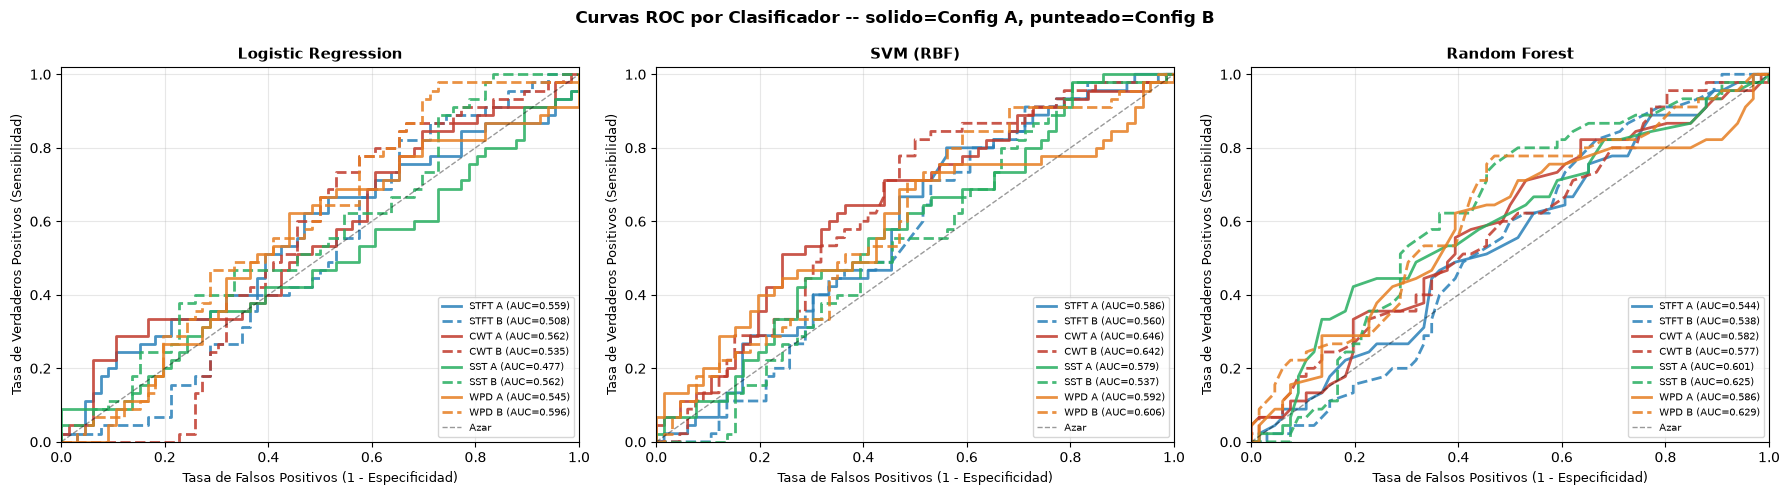

In [6]:
## Curvas ROC: las 4 técnicas por clasificador

linestyles = {'A (56 features)': '-', 'B (16 features)': '--'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas ROC por Clasificador -- solido=Config A, punteado=Config B',
             fontsize=12, fontweight='bold')

for clf_idx, clf_name in enumerate(list(classifiers.keys())):
    ax = axes[clf_idx]

    for tecnica in TECNICAS:
        for config in ['A (56 features)', 'B (16 features)']:
            r = next((x for x in results if x['Técnica'] == tecnica
                      and x['Config'] == config
                      and x['Clasificador'] == clf_name), None)
            if r is None or r['y_proba'] is None:
                continue
            fpr, tpr, _ = roc_curve(splits[tecnica]['y_te'], r['y_proba'])
            label = f"{tecnica} {config.split('(')[0].strip()} (AUC={r['auc']:.3f})"
            ax.plot(fpr, tpr, color=COLORS[tecnica],
                    linestyle=linestyles[config], linewidth=2, label=label, alpha=0.85)

    ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.4, label='Azar')
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=9)
    ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=9)
    ax.set_title(clf_name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()


## Sección 4: Tabla resumen — split único vs cross-validación

Esta tabla cruza ambas evaluaciones para responder:

- **¿El split único fue representativo?** Si `Acc(split) ≈ Acc_mean(CV)`, sí.
  Si `Acc(split)` es significativamente mayor que `Acc_mean(CV)`, el split único
  era optimista (ese fold particular era más fácil que el promedio).

- **¿Los resultados son estables?** Un `std` alto en CV indica que la performance
  depende mucho de qué parte del registro se usa como test — importante
  declararlo en el informe.

- **La columna BAcc(CV)** es la métrica más confiable del notebook porque combina
  corrección de distribución (balanced) con evaluación múltiple (CV).

In [7]:
## Tabla resumen final: split único vs cross-validación (24 combinaciones)

results_df_num = pd.DataFrame([
    {'Técnica': r['Técnica'], 'Config': r['Config'], 'Clasificador': r['Clasificador'],
     'Acc': r['acc'], 'BAcc': r['bacc'], 'F1': r['f1'], 'AUC': r['auc']}
    for r in results
])

summary_rows = []
for _, row_cv in cv_df.iterrows():
    row_sp = results_df_num[
        (results_df_num['Técnica']      == row_cv['Técnica']) &
        (results_df_num['Config']       == row_cv['Config']) &
        (results_df_num['Clasificador'] == row_cv['Clasificador'])
    ].iloc[0]
    summary_rows.append({
        'Técnica':      row_cv['Técnica'],
        'Config':       row_cv['Config'],
        'Clasificador': row_cv['Clasificador'],
        'Acc (split)':  f"{row_sp['Acc']:.3f}",
        'BAcc (split)': f"{row_sp['BAcc']:.3f}",
        'Acc (CV)':     f"{row_cv['Acc_mean']:.3f}+-{row_cv['Acc_std']:.3f}",
        'BAcc (CV)':    f"{row_cv['BAcc_mean']:.3f}+-{row_cv['BAcc_std']:.3f}",
        'F1 (CV)':      f"{row_cv['F1_mean']:.3f}+-{row_cv['F1_std']:.3f}",
        'AUC (CV)':     f"{row_cv['AUC_mean']:.3f}+-{row_cv['AUC_std']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 115)
print('TABLA RESUMEN: Split unico vs Cross-validacion (5-fold TimeSeriesSplit) -- 24 combinaciones')
print('=' * 115)
print(summary_df.to_string(index=False))


TABLA RESUMEN: Split unico vs Cross-validacion (5-fold TimeSeriesSplit) -- 24 combinaciones
Técnica          Config        Clasificador Acc (split) BAcc (split)     Acc (CV)    BAcc (CV)      F1 (CV)     AUC (CV)
   STFT A (56 features) Logistic Regression       0.514        0.545 0.505+-0.133 0.502+-0.117 0.479+-0.134 0.502+-0.196
   STFT A (56 features)           SVM (RBF)       0.577        0.612 0.505+-0.115 0.592+-0.060 0.498+-0.119 0.601+-0.096
   STFT A (56 features)       Random Forest       0.505        0.530 0.458+-0.081 0.533+-0.102 0.450+-0.087 0.519+-0.093
   STFT B (16 features) Logistic Regression       0.505        0.534 0.489+-0.149 0.518+-0.132 0.474+-0.153 0.510+-0.130
   STFT B (16 features)           SVM (RBF)       0.514        0.520 0.521+-0.077 0.543+-0.085 0.498+-0.093 0.513+-0.154
   STFT B (16 features)       Random Forest       0.541        0.550 0.432+-0.086 0.430+-0.148 0.420+-0.107 0.424+-0.142
    CWT A (56 features) Logistic Regression       0.514      

In [8]:
print('\n--- Ranking final por BAcc (CV) promedio por tecnica ---')
ranking_final = cv_df.groupby('Técnica')['BAcc_mean'].mean().loc[TECNICAS].sort_values(ascending=False)
for i, (tecnica, val) in enumerate(ranking_final.items(), 1):
    print(f'  {i}. {tecnica}: BAcc_mean = {val:.4f}')

print('\n--- Mejor combinacion individual segun BAcc (CV) ---')
best_cv = cv_df.loc[cv_df['BAcc_mean'].idxmax()]
print(f"{best_cv['Técnica']} + {best_cv['Config']} + {best_cv['Clasificador']}: "
      f"BAcc {best_cv['BAcc_mean']:.3f}+-{best_cv['BAcc_std']:.3f}, "
      f"AUC {best_cv['AUC_mean']:.3f}+-{best_cv['AUC_std']:.3f}")



--- Ranking final por BAcc (CV) promedio por tecnica ---
  1. WPD: BAcc_mean = 0.5375
  2. CWT: BAcc_mean = 0.5251
  3. STFT: BAcc_mean = 0.5199
  4. SST: BAcc_mean = 0.5138

--- Mejor combinacion individual segun BAcc (CV) ---
SST + A (56 features) + SVM (RBF): BAcc 0.607+-0.131, AUC 0.574+-0.157


## Sección 5: Importancia de features — comparación CON vs SIN ICA

Esta sección responde la pregunta fisiológica: **¿la limpieza ICA desplaza la importancia de los canales frontales (artefactos oculares) hacia los occipito-parietales (donde reside el ritmo alfa)?**

Metodología (idéntica para ambas variantes, para que la comparación sea justa):
- Mismo clasificador **Random Forest** y mismo **TimeSeriesSplit (5 folds)** de las secciones anteriores.
- Importancia **Gini promediada sobre los folds** (no de un split único, que ya demostramos ser inestable).
- **Config A (todos los canales)**, agregando las 4 features de cada canal para obtener importancia por canal y por región.
- Se contrastan las features de `data/features/features_*.csv` (**sin ICA**) contra `features_*_ica.csv` (**con ICA**), generadas por el mismo pipeline (02 → 03) desde la señal con/sin ICA.

> Nota: la comparación CON vs SIN ICA aplica solo a las 4 técnicas TF. Las topológicas (GSP/TSP) siempre se derivan de la señal ICA y no tienen contraparte sin-ICA, por lo que quedan fuera de este experimento.

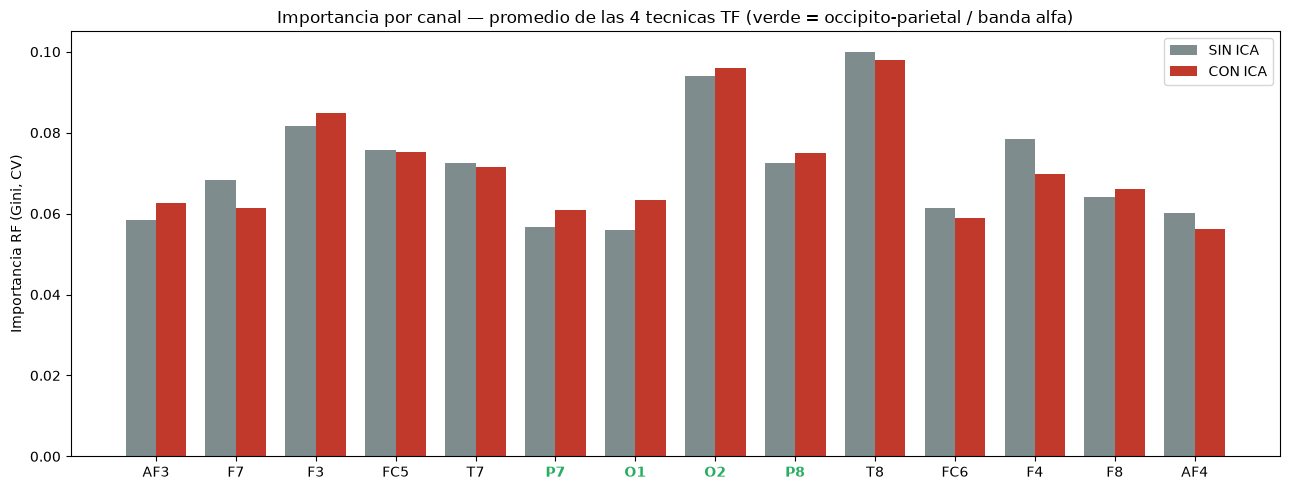

=== Importancia agregada por region (fraccion del total, promedio de las 4 tecnicas) ===
Region                   SIN ICA   CON ICA     Delta
Frontal                    0.548     0.535    -0.013
Temporal (T7/T8)           0.173     0.169    -0.003
Occipito-parietal          0.279     0.295    +0.016

--- Interpretacion ---
Cambio importancia occipito-parietal (alfa) con ICA: +0.016
Cambio importancia frontal con ICA:                  -0.013
=> ICA desplazo la importancia HACIA el alfa occipital (consistente con la hipotesis fisiologica).


In [9]:
## Importancia de features RF (CV) — CON vs SIN ICA
# Cargar variante CON ICA (mismas columnas/orden que la sin-ICA)
datasets_ica = {
    'STFT': pd.read_csv('data/features/features_stft_ica.csv'),
    'CWT':  pd.read_csv('data/features/features_cwt_ica.csv'),
    'SST':  pd.read_csv('data/features/features_sst_ica.csv'),
    'WPD':  pd.read_csv('data/features/features_wpd_ica.csv'),
}
Xs_ica = {n: d.drop('label', axis=1).values for n, d in datasets_ica.items()}
ys_ica = {n: d['label'].values              for n, d in datasets_ica.items()}

rf_template = classifiers['Random Forest']
featA = [feature_names[i] for i in idx_config_a]   # nombres de las 56 features de Config A

def rf_importance_cv(X, y):
    """Importancia Gini promediada sobre los folds del TimeSeriesSplit (Config A)."""
    imps = []
    for tr, _ in tscv.split(X):
        sc  = StandardScaler()
        Xtr = sc.fit_transform(X[tr][:, idx_config_a])
        rf  = clone(rf_template)
        rf.fit(Xtr, y[tr])
        imps.append(rf.feature_importances_)
    return np.mean(imps, axis=0)

def por_canal(imp_vec):
    """Agrega las 4 features de cada canal -> importancia por canal."""
    out = {}
    for ch in canales_todos:
        out[ch] = sum(imp_vec[featA.index(f'{ch}_{f}')]
                      for f in features_por_canal if f'{ch}_{f}' in featA)
    return out

imp_sin, imp_con = {}, {}
for tec in TECNICAS:
    imp_sin[tec] = por_canal(rf_importance_cv(Xs[tec],     ys[tec]))
    imp_con[tec] = por_canal(rf_importance_cv(Xs_ica[tec], ys_ica[tec]))

# Promedio entre las 4 tecnicas
imp_sin_avg = {ch: np.mean([imp_sin[t][ch] for t in TECNICAS]) for ch in canales_todos}
imp_con_avg = {ch: np.mean([imp_con[t][ch] for t in TECNICAS]) for ch in canales_todos}

# --- Grafico 1: importancia por canal, sin vs con ICA (promedio entre tecnicas) ---
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(canales_todos)); w = 0.38
ax.bar(x - w/2, [imp_sin_avg[c] for c in canales_todos], w, label='SIN ICA', color='#7f8c8d')
ax.bar(x + w/2, [imp_con_avg[c] for c in canales_todos], w, label='CON ICA', color='#c0392b')
region_color = {'O1':'#27ae60','O2':'#27ae60','P7':'#27ae60','P8':'#27ae60'}
for i, c in enumerate(canales_todos):
    ax.get_xticklabels()
ax.set_xticks(x); ax.set_xticklabels(canales_todos)
for tl in ax.get_xticklabels():
    if tl.get_text() in ('O1','O2','P7','P8'):
        tl.set_color('#27ae60'); tl.set_fontweight('bold')
ax.set_ylabel('Importancia RF (Gini, CV)'); ax.set_title('Importancia por canal — promedio de las 4 tecnicas TF (verde = occipito-parietal / banda alfa)')
ax.legend(); plt.tight_layout()
plt.savefig('files/importancia_features_ica.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Resumen por region ---
frontales   = ['AF3','F7','F3','FC5','FC6','F4','F8','AF4']
temporales  = ['T7','T8']
occ_pariet  = ['O1','O2','P7','P8']
def region_sum(d, region): return sum(d[ch] for ch in region)

print('=== Importancia agregada por region (fraccion del total, promedio de las 4 tecnicas) ===')
print(f"{'Region':<22}{'SIN ICA':>10}{'CON ICA':>10}{'Delta':>10}")
for nombre, reg in [('Frontal', frontales), ('Temporal (T7/T8)', temporales), ('Occipito-parietal', occ_pariet)]:
    s, c = region_sum(imp_sin_avg, reg), region_sum(imp_con_avg, reg)
    print(f'{nombre:<22}{s:>10.3f}{c:>10.3f}{c-s:>+10.3f}')

d_occ = region_sum(imp_con_avg, occ_pariet) - region_sum(imp_sin_avg, occ_pariet)
d_fro = region_sum(imp_con_avg, frontales)  - region_sum(imp_sin_avg, frontales)
print('\n--- Interpretacion ---')
print(f'Cambio importancia occipito-parietal (alfa) con ICA: {d_occ:+.3f}')
print(f'Cambio importancia frontal con ICA:                  {d_fro:+.3f}')
if d_occ > 0 and d_fro < 0:
    print('=> ICA desplazo la importancia HACIA el alfa occipital (consistente con la hipotesis fisiologica).')
else:
    print('=> ICA NO desplazo la importancia hacia el alfa occipital (resultado contra-intuitivo: ver discusion).')


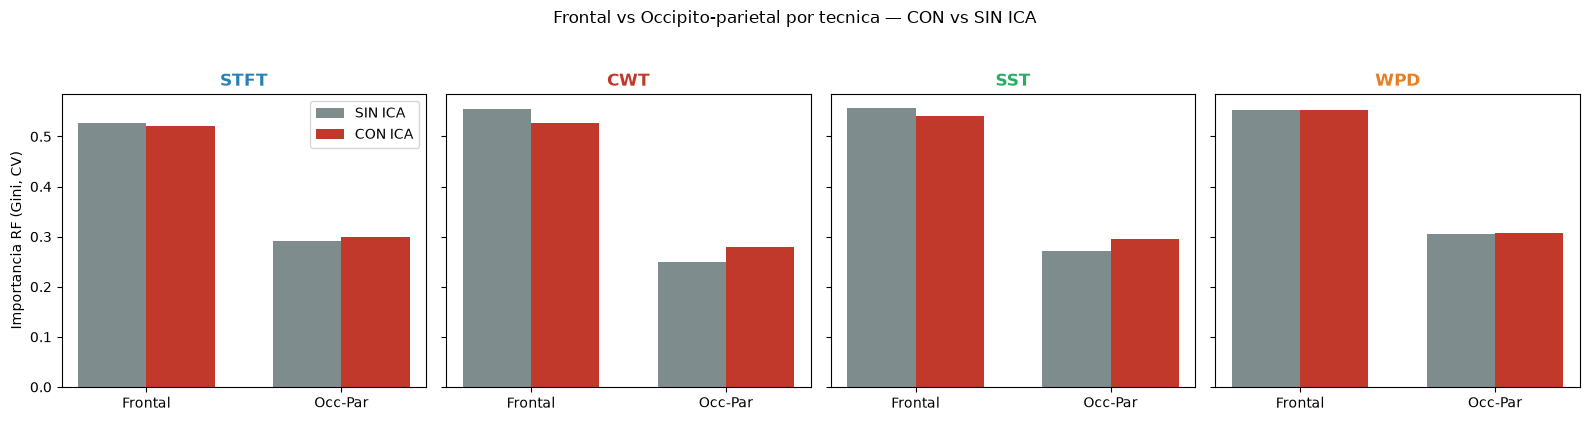

Ranking de canales por importancia (CON ICA, promedio de tecnicas):
  T8: 0.098
  O2: 0.096
  F3: 0.085
  FC5: 0.075
  P8: 0.075
  T7: 0.072


In [10]:
## Detalle por tecnica: importancia occipito-parietal vs frontal, CON vs SIN ICA
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
frontales  = ['AF3','F7','F3','FC5','FC6','F4','F8','AF4']
occ_pariet = ['O1','O2','P7','P8']
for ax, tec in zip(axes, TECNICAS):
    fo_sin = sum(imp_sin[tec][c] for c in frontales);  oc_sin = sum(imp_sin[tec][c] for c in occ_pariet)
    fo_con = sum(imp_con[tec][c] for c in frontales);  oc_con = sum(imp_con[tec][c] for c in occ_pariet)
    xx = np.arange(2); w = 0.35
    ax.bar(xx - w/2, [fo_sin, oc_sin], w, label='SIN ICA', color='#7f8c8d')
    ax.bar(xx + w/2, [fo_con, oc_con], w, label='CON ICA', color='#c0392b')
    ax.set_xticks(xx); ax.set_xticklabels(['Frontal', 'Occ-Par'])
    ax.set_title(tec, color=COLORS[tec], fontweight='bold')
axes[0].set_ylabel('Importancia RF (Gini, CV)'); axes[0].legend()
plt.suptitle('Frontal vs Occipito-parietal por tecnica — CON vs SIN ICA', y=1.04)
plt.tight_layout()
plt.savefig('files/importancia_region_por_tecnica_ica.png', dpi=120, bbox_inches='tight')
plt.show()

print('Ranking de canales por importancia (CON ICA, promedio de tecnicas):')
for ch, v in sorted(imp_con_avg.items(), key=lambda kv: kv[1], reverse=True)[:6]:
    print(f'  {ch}: {v:.3f}')


## Sección 6: Comparación de rendimiento robusto — CON vs SIN ICA

Complementa la Sección 5 (importancia): ahora se compara el **rendimiento de clasificación** sin-ICA vs con-ICA bajo **cross-validación temporal (TimeSeriesSplit, 5 folds)** — la métrica más confiable del proyecto. Mismas 24 combinaciones, mismo escalado por fold. Métricas: **Balanced Accuracy** y **AUC** promediadas sobre folds.

In [11]:
## Rendimiento CV (BAcc/AUC) CON vs SIN ICA — mismas 24 combinaciones
def _cv_perf(X, y):
    rows = []
    for cfg, idx in [('A (56 features)', idx_config_a), ('B (16 features)', idx_config_b)]:
        Xc = X[:, idx]
        for clf_name, clf in classifiers.items():
            baccs, aucs = [], []
            for tr, te in tscv.split(Xc):
                sc = StandardScaler()
                Xtr = sc.fit_transform(Xc[tr]); Xte = sc.transform(Xc[te])
                m = clone(clf); m.fit(Xtr, y[tr]); yp = m.predict(Xte)
                baccs.append(balanced_accuracy_score(y[te], yp))
                if hasattr(m, 'predict_proba') and len(np.unique(y[te])) > 1:
                    aucs.append(roc_auc_score(y[te], m.predict_proba(Xte)[:, 1]))
            rows.append({'Config': cfg, 'Clasificador': clf_name,
                         'BAcc': np.mean(baccs), 'AUC': np.mean(aucs) if aucs else np.nan})
    return pd.DataFrame(rows)

perf_sin, perf_con = [], []
for tec in TECNICAS:
    a = _cv_perf(Xs[tec],     ys[tec]);     a['Técnica'] = tec; perf_sin.append(a)
    b = _cv_perf(Xs_ica[tec], ys_ica[tec]); b['Técnica'] = tec; perf_con.append(b)
perf_sin = pd.concat(perf_sin, ignore_index=True)
perf_con = pd.concat(perf_con, ignore_index=True)

print('=== Promedio global (24 combinaciones, CV) ===')
for m in ['BAcc', 'AUC']:
    s, c = perf_sin[m].mean(), perf_con[m].mean()
    print(f'  {m:5s}  SIN ICA: {s:.4f}   CON ICA: {c:.4f}   Δ: {c-s:+.4f}')

print('\n=== Por técnica (BAcc / AUC promedio, CV) ===')
print(f"{'Téc':5s}{'BAcc sin':>10}{'BAcc ICA':>10}{'Δ':>8}   {'AUC sin':>9}{'AUC ICA':>9}{'Δ':>8}")
for t in TECNICAS:
    bs = perf_sin[perf_sin['Técnica']==t]['BAcc'].mean(); bc = perf_con[perf_con['Técnica']==t]['BAcc'].mean()
    as_ = perf_sin[perf_sin['Técnica']==t]['AUC'].mean(); ac = perf_con[perf_con['Técnica']==t]['AUC'].mean()
    print(f'{t:5s}{bs:>10.4f}{bc:>10.4f}{bc-bs:>+8.4f}   {as_:>9.4f}{ac:>9.4f}{ac-as_:>+8.4f}')

mejor_sin = perf_sin.loc[perf_sin['BAcc'].idxmax()]
mejor_con = perf_con.loc[perf_con['BAcc'].idxmax()]
print(f"\nMejor combinacion SIN ICA: {mejor_sin['Técnica']} {mejor_sin['Config']} {mejor_sin['Clasificador']} -> BAcc {mejor_sin['BAcc']:.4f}")
print(f"Mejor combinacion CON ICA: {mejor_con['Técnica']} {mejor_con['Config']} {mejor_con['Clasificador']} -> BAcc {mejor_con['BAcc']:.4f}")


=== Promedio global (24 combinaciones, CV) ===
  BAcc   SIN ICA: 0.5241   CON ICA: 0.5248   Δ: +0.0008
  AUC    SIN ICA: 0.5260   CON ICA: 0.5354   Δ: +0.0094

=== Por técnica (BAcc / AUC promedio, CV) ===
Téc    BAcc sin  BAcc ICA       Δ     AUC sin  AUC ICA       Δ
STFT     0.5199    0.5437 +0.0238      0.5114   0.5607 +0.0494
CWT      0.5251    0.5288 +0.0037      0.5522   0.5522 -0.0000
SST      0.5138    0.5061 -0.0077      0.5246   0.5233 -0.0013
WPD      0.5375    0.5208 -0.0167      0.5158   0.5054 -0.0104

Mejor combinacion SIN ICA: SST A (56 features) SVM (RBF) -> BAcc 0.6072
Mejor combinacion CON ICA: CWT A (56 features) Random Forest -> BAcc 0.6150


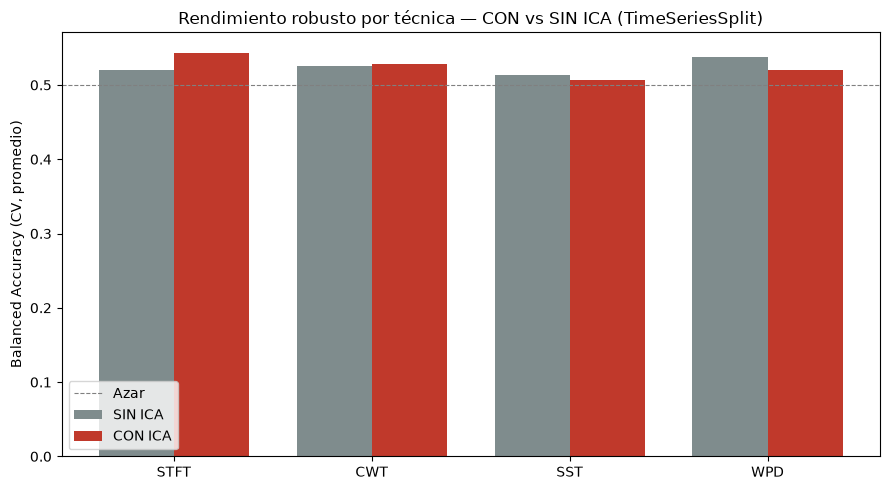

In [12]:
## Grafico: BAcc promedio por tecnica, SIN vs CON ICA (CV temporal)
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(TECNICAS)); w = 0.38
bsin = [perf_sin[perf_sin['Técnica']==t]['BAcc'].mean() for t in TECNICAS]
bcon = [perf_con[perf_con['Técnica']==t]['BAcc'].mean() for t in TECNICAS]
ax.bar(x - w/2, bsin, w, label='SIN ICA', color='#7f8c8d')
ax.bar(x + w/2, bcon, w, label='CON ICA', color='#c0392b')
ax.axhline(0.5, ls='--', c='gray', lw=0.8, label='Azar')
ax.set_xticks(x); ax.set_xticklabels(TECNICAS)
ax.set_ylabel('Balanced Accuracy (CV, promedio)')
ax.set_title('Rendimiento robusto por técnica — CON vs SIN ICA (TimeSeriesSplit)')
ax.legend(); plt.tight_layout()
plt.savefig('files/comparacion_ica_07.png', dpi=120, bbox_inches='tight')
plt.show()
